# Connectivity (trial-shuffle xcorr)

Exploratory visualization of Insula–partner coupling from
`run_xcorr_pair_permutation.py` outputs:

- Input: `../results/{Task}(bipolar)/sub-*/xcorr/*_perm.{csv,nc}`
- Channel ROI/coords: Hammers HGA `*_coord.csv` (AIC/PIC already labeled)
- Logic adapted from `vizpub/fig2_legacy.ipynb` Connectivity section

Figures are shown inline (no export required). Style follows
[`docs/PLOTTING_STYLE.md`](../docs/PLOTTING_STYLE.md).

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
from IPython.display import display
from mne_bids import BIDSPath
from tqdm.auto import tqdm

In [2]:
cm = 1 / 2.54
plt.rcParams["svg.fonttype"] = "none"

fontdict = dict(fontsize=7)
fontsize = 7

red = "#A9373B"
blue = "#2369BD"
orange = "#CC8963"
green = "#009944"

RESULTS = Path("../results")
RECON_DIR = "/cwork/ns458/ECoG_Recon/"

## Config

`TASK_ROOTS` maps the analysis task name to the on-disk results folder.
Phoneme xcorr outputs live under `PhonemeSequencing(bipolar)` (BIDS task name).

In [3]:
REF = "bipolar"
ATLAS = "hammers"
DESCRIPTION = "Repeat"
BAND = "highgamma"

# analysis label -> results/{root}(bipolar)
TASK_ROOTS = {
    "LexicalDelay": "LexicalDelay",
    "LexicalNoDelay": "LexicalNoDelay",
    "PhonemeSequence": "PhonemeSequencing",  # BIDS task name on disk
    "PictureNaming": "PictureNaming",
    "SentenceRep": "SentenceRep",
}

# HGA coord packaging uses the analysis task names
HGA_TASKS = [
    "LexicalDelay",
    "LexicalNoDelay",
    "PhonemeSequence",
    "PictureNaming",
    "SentenceRep",
]

MIN_PEAK_VAL = 0.05
MAX_ABS_LAG_S = 0.5
FOCUS_ROIS = ["AIC", "PIC"]
PHASES = ["stimulus", "delay", "go", "response"]

EXCLUDE_ROIS = {"Intersection", "LinG", "OccS", "CollatAnt", "Central", "Unknown"}
ROI_MAP = {"MFGs": "MFG", "IFGs": "IFG", "SFGs": "SFG", "OFCs": "OFC"}

## Load channel metadata (Hammers coords)

Use `*_coord.csv` (lighter than full HGA time series) for `channel → roi/hemi/xyz`.

In [4]:
coord_paths = []
for t in HGA_TASKS:
    root = RESULTS / f"{t}({REF})({ATLAS})"
    if not root.exists():
        print(f"[skip HGA] missing {root}")
        continue
    coord_paths.extend(
        BIDSPath(
            root=str(root),
            datatype="HGA",
            suffix="coord",
            description=DESCRIPTION,
            check=False,
        ).match()
    )

if not coord_paths:
    raise FileNotFoundError(
        f"No coord CSVs under results/{{task}}({REF})({ATLAS})/HGA/"
    )

coords = pd.concat(
    [pd.read_csv(p) for p in tqdm(coord_paths, desc="load coords")],
    ignore_index=True,
)

# Hammers ROI groupings (same as vizpub/fig2.ipynb)
coords.loc[coords.roi == "PrG", "roi"] = "SMC"
coords.loc[coords.roi == "PoG", "roi"] = "SMC"
coords.loc[coords.roi == "Subcentral", "roi"] = "SMC"
coords.loc[coords.roi == "STGp", "roi"] = "STG"
coords.loc[coords.roi == "STGa", "roi"] = "STG"
coords.loc[coords.roi == "HG", "roi"] = "STG"

channel_meta = (
    coords[["channel", "roi", "hemi", "x", "y", "z"]]
    .dropna(subset=["channel", "roi"])
    .groupby("channel", as_index=False)
    .first()
)

exclude_path = RESULTS / "exlude_insula.csv"
exclude_chn = []
if exclude_path.exists():
    exclude_df = pd.read_csv(exclude_path, index_col=0)
    exclude_chn = [
        electrode
        for item in exclude_df.Exclude.dropna()
        for electrode in eval(item)
    ]
    channel_meta = channel_meta[~channel_meta.channel.isin(exclude_chn)].copy()

print(f"Channels: {len(channel_meta)}")
print(f"AIC: {(channel_meta.roi == 'AIC').sum()}  PIC: {(channel_meta.roi == 'PIC').sum()}")
channel_meta.head()

[skip HGA] missing ../results/SentenceRep(bipolar)(hammers)


load coords:   0%|          | 0/721 [00:00<?, ?it/s]

Channels: 13933
AIC: 280  PIC: 158


,channel,roi,hemi,x,y,z
0,D0019_RIIH1-2,LinG,R,8.41703,-44.3481,-20.64296
1,D0019_RIIH2-3,LinG,R,4.62597,-55.4648,-17.93574
2,D0019_RIIH3-4,LinG,R,4.06682,-64.4239,-15.98172
3,D0019_RIIH4-5,LinG–Cun,R,5.34089,-73.6314,-12.22795
4,D0019_RLOS1-2,AG,R,52.64330,-39.8362,33.99210


## Load xcorr permutation results

Load cluster tables (`*_perm.csv`) for all tasks/phases. Waveform NetCDF files
are loaded lazily when extracting peak lag/value.

In [5]:
all_clusters = []

for task_name, disk_root in TASK_ROOTS.items():
    results_root = RESULTS / f"{disk_root}({REF})"
    if not results_root.exists():
        print(f"[skip] missing {results_root}")
        continue

    base = BIDSPath(
        root=str(results_root),
        datatype="xcorr",
        recording=BAND,
        description=DESCRIPTION,
        suffix="perm",
        check=False,
    )
    csv_paths = base.copy().update(extension=".csv").match()
    print(f"[{task_name}] root={disk_root}  csv={len(csv_paths)}")

    for p in csv_paths:
        df = pd.read_csv(p.fpath)
        df["task"] = task_name
        df["phase"] = p.processing
        df["description"] = p.description
        df["file"] = str(p.fpath)
        all_clusters.append(df)

if not all_clusters:
    raise FileNotFoundError("No *_perm.csv files found under results/")

clusters_df = pd.concat(all_clusters, ignore_index=True)
print(f"Total cluster rows: {len(clusters_df)}")
print(clusters_df.groupby(["task", "phase"]).size().unstack(fill_value=0))
clusters_df.head()

[LexicalDelay] root=LexicalDelay  csv=202
[LexicalNoDelay] root=LexicalNoDelay  csv=45
[PhonemeSequence] root=PhonemeSequencing  csv=188
[PictureNaming] root=PictureNaming  csv=0
[SentenceRep] root=SentenceRep  csv=62
Total cluster rows: 17837
phase            Delay    Go  Response  Stimulus
task                                            
LexicalDelay      1406  1352      2182      1326
LexicalNoDelay       0     0       752       440
PhonemeSequence    756   948      1415       865
SentenceRep        136    19      6089       151


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_356045/1975149483.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  clusters_df = pd.concat(all_clusters, ignore_index=True)


,pair_idx,source_channel,target_channel,lag_start_s,lag_end_s,mass,p_value,significant,task,phase,description,file
0,18,D0023_RMSF6-7,D0023_RPIF2-3,0.046875,0.101562,0.086353,0.047952,True,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
1,13,D0023_RPIF9-10,D0023_R2MF8-9,-0.078125,-0.015625,0.111508,0.040959,True,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
2,26,D0023_RPMF12-13,D0023_R2MF10-11,0.023438,0.109375,0.212033,0.006993,True,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
3,28,D0023_RPMF12-13,D0023_R2MF9-10,-0.171875,-0.093750,0.107221,0.042957,True,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
4,37,D0023_RPMF12-13,D0023_RPMF1-2,-0.250000,-0.179688,0.103120,0.047952,True,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...


## Merge ROI labels onto significant clusters

In [6]:
sig_roi_df = (
    clusters_df.loc[clusters_df["significant"] == True]
    .copy()
    .merge(
        channel_meta.rename(
            columns={
                "channel": "source_channel",
                "roi": "source_roi",
                "hemi": "source_hemi",
                "x": "source_x",
                "y": "source_y",
                "z": "source_z",
            }
        ),
        on="source_channel",
        how="left",
    )
    .merge(
        channel_meta.rename(
            columns={
                "channel": "target_channel",
                "roi": "target_roi",
                "hemi": "target_hemi",
                "x": "target_x",
                "y": "target_y",
                "z": "target_z",
            }
        ),
        on="target_channel",
        how="left",
    )
)

print("sig rows:", len(sig_roi_df))
print("missing source_roi:", sig_roi_df["source_roi"].isna().sum())
print("missing target_roi:", sig_roi_df["target_roi"].isna().sum())
sig_roi_df.head()

sig rows: 17837
missing source_roi: 959
missing target_roi: 959


,pair_idx,source_channel,target_channel,lag_start_s,lag_end_s,mass,p_value,significant,task,phase,...,source_roi,source_hemi,source_x,source_y,source_z,target_roi,target_hemi,target_x,target_y,target_z
0,18,D0023_RMSF6-7,D0023_RPIF2-3,0.046875,0.101562,0.086353,0.047952,True,LexicalDelay,Delay,...,SFG,R,15.5138,35.3361,21.1440,SMG,R,41.62430,-11.54200,-1.6901
1,13,D0023_RPIF9-10,D0023_R2MF8-9,-0.078125,-0.015625,0.111508,0.040959,True,LexicalDelay,Go,...,SMG,R,66.9825,-15.8252,2.2064,SMC,R,34.77700,9.01466,19.9182
2,26,D0023_RPMF12-13,D0023_R2MF10-11,0.023438,0.109375,0.212033,0.006993,True,LexicalDelay,Go,...,SMC,R,51.3652,-7.7959,20.7479,SMC,R,42.41840,8.79105,19.3140
3,28,D0023_RPMF12-13,D0023_R2MF9-10,-0.171875,-0.093750,0.107221,0.042957,True,LexicalDelay,Go,...,SMC,R,51.3652,-7.7959,20.7479,SMC,R,38.68610,8.81294,19.5575
4,37,D0023_RPMF12-13,D0023_RPMF1-2,-0.250000,-0.179688,0.103120,0.047952,True,LexicalDelay,Go,...,SMC,R,51.3652,-7.7959,20.7479,CG,R,8.00588,-1.51500,21.8557


## Extract peak lag / strength inside each significant cluster

For each significant lag-cluster, load the matching `*_perm.nc` pair curve and
take the peak within the cluster window.

In [7]:
ds_cache = {}


def get_ds(nc_file: str):
    if nc_file not in ds_cache:
        ds_cache[nc_file] = xr.load_dataset(nc_file)
    return ds_cache[nc_file]


sig = sig_roi_df.copy()
sig["nc_file"] = sig["file"].apply(lambda x: str(Path(x).with_suffix(".nc")))

peak_rows = []
n_skip_pair_idx = 0
n_skip_empty_window = 0
n_skip_all_nan = 0
n_skip_missing_nc = 0

for _, row in tqdm(sig.iterrows(), total=len(sig), desc="extract peaks"):
    nc_file = row["nc_file"]
    if not Path(nc_file).exists():
        n_skip_missing_nc += 1
        continue

    pair_idx = int(row["pair_idx"])
    lag_start = float(row["lag_start_s"])
    lag_end = float(row["lag_end_s"])

    ds = get_ds(nc_file)
    if pair_idx < 0 or pair_idx >= ds.sizes["pair"]:
        n_skip_pair_idx += 1
        continue

    obs = ds["observed_curve"].isel(pair=pair_idx).values
    nul = ds["null_mean"].isel(pair=pair_idx).values
    lag = ds["lag"].values

    mask = (lag >= lag_start) & (lag <= lag_end)
    if not mask.any():
        n_skip_empty_window += 1
        continue

    lag_in_cluster = lag[mask]
    obs_in_cluster = obs[mask]
    if np.all(~np.isfinite(obs_in_cluster)):
        n_skip_all_nan += 1
        continue

    peak_idx_local = int(np.nanargmax(obs_in_cluster))
    peak_lag = float(lag_in_cluster[peak_idx_local])
    peak_val = float(obs_in_cluster[peak_idx_local])
    peak_idx_global = int(np.argmin(np.abs(lag - peak_lag)))
    null_at_peak = float(nul[peak_idx_global])

    if peak_lag > 0.01:
        direction = "source_leads"
    elif peak_lag < -0.01:
        direction = "target_leads"
    else:
        direction = "near_zero"

    peak_rows.append(
        {
            "task": row["task"],
            "phase": row["phase"],
            "description": row["description"],
            "pair_idx": pair_idx,
            "source_channel": row["source_channel"],
            "target_channel": row["target_channel"],
            "source_roi": row.get("source_roi"),
            "target_roi": row.get("target_roi"),
            "source_hemi": row.get("source_hemi"),
            "target_hemi": row.get("target_hemi"),
            "lag_start_s": lag_start,
            "lag_end_s": lag_end,
            "peak_lag_s": peak_lag,
            "peak_val": peak_val,
            "null_at_peak": null_at_peak,
            "peak_excess": peak_val - null_at_peak,
            "is_near_zero": abs(peak_lag) < 0.05,
            "in_range": abs(peak_lag) <= MAX_ABS_LAG_S,
            "direction": direction,
            "p_value": row.get("p_value"),
            "file": row["file"],
        }
    )

peaks_df_raw = pd.DataFrame(peak_rows)
peaks_df = peaks_df_raw[
    (peaks_df_raw["peak_val"] >= MIN_PEAK_VAL)
    & (peaks_df_raw["peak_lag_s"].abs() <= MAX_ABS_LAG_S)
].copy()

print(f"Total significant clusters (raw): {len(peaks_df_raw)}")
print(f"After filter peak_val>={MIN_PEAK_VAL} & |lag|<={MAX_ABS_LAG_S}s: {len(peaks_df)}")
print(f"Near-zero peaks (|lag|<0.05s): {peaks_df['is_near_zero'].sum()}")
print(f"Skipped missing nc / pair_idx / empty / nan: "
      f"{n_skip_missing_nc} / {n_skip_pair_idx} / {n_skip_empty_window} / {n_skip_all_nan}")
peaks_df.head()

extract peaks:   0%|          | 0/17837 [00:00<?, ?it/s]

Total significant clusters (raw): 17837
After filter peak_val>=0.05 & |lag|<=0.5s: 16797
Near-zero peaks (|lag|<0.05s): 8127
Skipped missing nc / pair_idx / empty / nan: 0 / 0 / 0 / 0


,task,phase,description,pair_idx,source_channel,target_channel,source_roi,target_roi,source_hemi,target_hemi,...,lag_end_s,peak_lag_s,peak_val,null_at_peak,peak_excess,is_near_zero,in_range,direction,p_value,file
0,LexicalDelay,Delay,Repeat,18,D0023_RMSF6-7,D0023_RPIF2-3,SFG,SMG,R,R,...,0.101562,0.078125,0.058409,0.046071,0.012337,False,True,source_leads,0.047952,../results/LexicalDelay(bipolar)/sub-D0023/xco...
1,LexicalDelay,Go,Repeat,13,D0023_RPIF9-10,D0023_R2MF8-9,SMG,SMC,R,R,...,-0.015625,-0.046875,0.064784,0.051153,0.013631,True,True,target_leads,0.040959,../results/LexicalDelay(bipolar)/sub-D0023/xco...
2,LexicalDelay,Go,Repeat,26,D0023_RPMF12-13,D0023_R2MF10-11,SMC,SMC,R,R,...,0.109375,0.054688,0.079921,0.058638,0.021283,False,True,source_leads,0.006993,../results/LexicalDelay(bipolar)/sub-D0023/xco...
3,LexicalDelay,Go,Repeat,28,D0023_RPMF12-13,D0023_R2MF9-10,SMC,SMC,R,R,...,-0.093750,-0.117188,0.058623,0.048100,0.010523,False,True,target_leads,0.042957,../results/LexicalDelay(bipolar)/sub-D0023/xco...
4,LexicalDelay,Go,Repeat,37,D0023_RPMF12-13,D0023_RPMF1-2,SMC,CG,R,R,...,-0.179688,-0.218750,0.053504,0.040165,0.013339,False,True,target_leads,0.047952,../results/LexicalDelay(bipolar)/sub-D0023/xco...


## Partner composition (AIC / PIC)

Stacked bars: for each phase, how many unique significant pairs link AIC/PIC
to each top partner ROI (self-connections excluded).

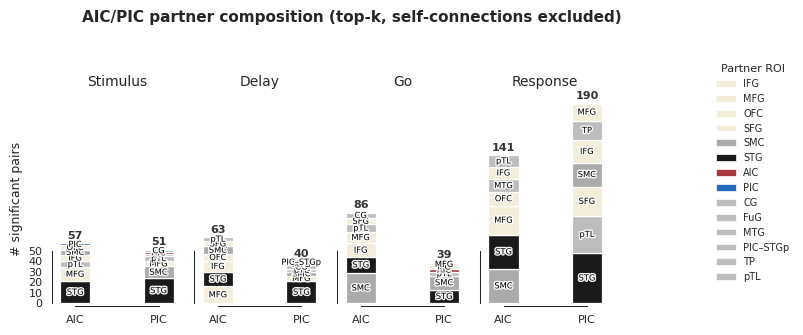

In [8]:
top_k = 7
label_inside_min = 2

df = peaks_df.copy()
df["source_roi"] = df["source_roi"].replace(ROI_MAP)
df["target_roi"] = df["target_roi"].replace(ROI_MAP)
df["phase_norm"] = df["phase"].astype(str).str.lower().str.strip()

df = df.dropna(subset=["source_roi", "target_roi", "source_channel", "target_channel", "phase_norm"])
df = df[
    (~df["source_roi"].isin(EXCLUDE_ROIS))
    & (~df["target_roi"].isin(EXCLUDE_ROIS))
    & (df["phase_norm"].isin(PHASES))
].copy()

ab = np.sort(df[["source_channel", "target_channel"]].values, axis=1)
df["pair_key"] = ab[:, 0] + "||" + ab[:, 1]

rows = []
for focus in FOCUS_ROIS:
    tmp = df[(df["source_roi"] == focus) | (df["target_roi"] == focus)].copy()
    tmp = tmp[~((tmp["source_roi"] == focus) & (tmp["target_roi"] == focus))].copy()
    if tmp.empty:
        continue
    tmp["focus_roi"] = focus
    tmp["partner_roi"] = np.where(tmp["source_roi"] == focus, tmp["target_roi"], tmp["source_roi"])
    rows.append(tmp[["phase_norm", "focus_roi", "partner_roi", "pair_key"]])

if not rows:
    raise RuntimeError("No rows left after filtering for partner composition.")

long_df = pd.concat(rows, ignore_index=True)
agg = (
    long_df.groupby(["phase_norm", "focus_roi", "partner_roi"], as_index=False)
    .agg(n_pairs=("pair_key", "nunique"))
)

top_chunks = []
for ph in PHASES:
    for focus in FOCUS_ROIS:
        sub = agg[(agg["phase_norm"] == ph) & (agg["focus_roi"] == focus)].copy()
        if sub.empty:
            continue
        top_chunks.append(sub.sort_values("n_pairs", ascending=False).head(top_k))

top_df = pd.concat(top_chunks, ignore_index=True)
partners = sorted(top_df["partner_roi"].unique())

partner2color = {
    "IFG": "#f3eed9",
    "MFG": "#f3eed9",
    "OFC": "#f3eed9",
    "SFG": "#f3eed9",
    "SMC": "#ababab",
    "STG": "#1A1A1A",
    "STS": "#1A1A1A",
    "Thal": "#2C8DA8",
    "dACC": "#6FB3C8",
    "AIC": red,
    "PIC": blue,
}
for p in partners:
    partner2color.setdefault(p, "#bdbdbd")

sns.set_theme(style="white")
fig, axes = plt.subplots(1, len(PHASES), figsize=(1.8 * len(PHASES), 3.4), sharey=True)
if len(PHASES) == 1:
    axes = [axes]

for ax, ph in zip(axes, PHASES):
    x_pos = np.array([0, 1])
    bar_width = 0.36
    totals = []

    for i, focus in enumerate(FOCUS_ROIS):
        sub = top_df[(top_df["phase_norm"] == ph) & (top_df["focus_roi"] == focus)].copy()
        bottom = 0
        if sub.empty:
            totals.append(0)
            continue

        for _, r in sub.sort_values("n_pairs", ascending=False).iterrows():
            v = r["n_pairs"]
            p = r["partner_roi"]
            ax.bar(
                x_pos[i], v, width=bar_width, bottom=bottom,
                color=partner2color[p], edgecolor="white", linewidth=0.9,
            )
            if v >= label_inside_min:
                t = ax.text(
                    x_pos[i], bottom + v / 2, p,
                    ha="center", va="center", fontsize=6, fontweight="medium", color="black",
                )
                t.set_path_effects([pe.withStroke(linewidth=2, foreground="white", alpha=0.95)])
            bottom += v
        totals.append(bottom)

    ax.set_title(ph.capitalize(), fontsize=10, fontweight="medium", pad=6)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(FOCUS_ROIS, fontsize=8)
    ax.tick_params(labelsize=8, width=0.8, length=3)
    for spine in ax.spines.values():
        spine.set_linewidth(0.75)
    sns.despine(ax=ax, offset=2, trim=True)
    for i, t in enumerate(totals):
        ax.text(x_pos[i], t + 2.5, f"{int(t)}", ha="center", va="bottom",
                fontsize=8, fontweight="bold", color="#333")

axes[0].set_ylabel("# significant pairs", fontsize=9)

legend_order = ["IFG", "MFG", "OFC", "SFG", "SMC", "STG", "STS", "Thal", "dACC", "AIC", "PIC"]
legend_partners = [p for p in legend_order if p in partners] + [p for p in partners if p not in legend_order]
handles = [
    plt.Rectangle((0, 0), 1, 1, color=partner2color[p], ec="white", lw=0.5)
    for p in legend_partners
]
fig.legend(
    handles, legend_partners, title="Partner ROI",
    loc="center right", bbox_to_anchor=(1.12, 0.5),
    ncol=1, frameon=False, fontsize=7, title_fontsize=8,
)
fig.suptitle(
    "AIC/PIC partner composition (top-k, self-connections excluded)",
    fontsize=11, fontweight="bold", y=0.98,
)
plt.tight_layout(rect=[0, 0, 0.88, 0.94])
plt.show()

## Phase × partner heatmap

Unique significant pair counts for AIC (left) and PIC (right).

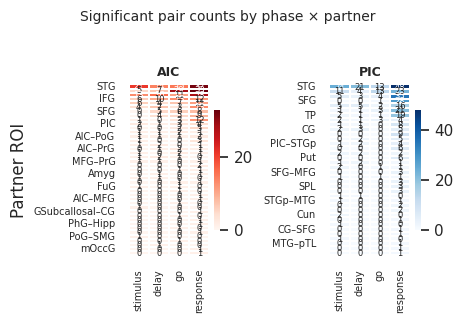

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12 * cm, 8 * cm), sharey=False)

for ax, focus in zip(axes, FOCUS_ROIS):
    sub = agg[agg["focus_roi"] == focus].copy()
    if sub.empty:
        ax.set_title(focus)
        ax.axis("off")
        continue

    mat = (
        sub.pivot_table(
            index="partner_roi", columns="phase_norm", values="n_pairs", fill_value=0
        )
        .reindex(columns=[p for p in PHASES if p in sub["phase_norm"].unique()], fill_value=0)
    )
    # order partners by total count
    mat = mat.loc[mat.sum(axis=1).sort_values(ascending=False).index]

    sns.heatmap(
        mat, ax=ax, cmap="Reds" if focus == "AIC" else "Blues",
        annot=True, fmt=".0f", annot_kws={"fontsize": 6},
        cbar_kws={"shrink": 0.7},
        linewidths=0.3, linecolor="white",
    )
    ax.set_title(focus, fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Partner ROI" if focus == "AIC" else "")
    ax.tick_params(labelsize=7)

fig.suptitle("Significant pair counts by phase × partner", fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

## Lag strip (Delay, AIC)

Each vertical tick is one unique electrode pair (mean lag across tasks).
Open circles = subject-balanced center lag per partner ROI.

- Negative: AIC leads
- Positive: AIC lags

Partners: ['MFG', 'OFC', 'STG', 'SMC', 'IFG']
Total pairs: 44


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_356045/3045574624.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(len(subjects), 1))


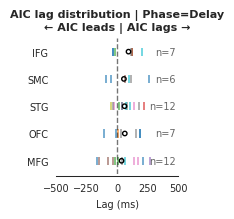

In [10]:
phase_keep = "delay"
focus_roi = "AIC"
top_k_lag = 5
min_lag_ms = 5

df = peaks_df.copy()
df["source_roi"] = df["source_roi"].replace(ROI_MAP)
df["target_roi"] = df["target_roi"].replace(ROI_MAP)
df["phase_norm"] = df["phase"].astype(str).str.lower().str.strip()

df = df[
    (~df["source_roi"].isin(EXCLUDE_ROIS))
    & (~df["target_roi"].isin(EXCLUDE_ROIS))
    & (df["phase_norm"] == phase_keep)
].copy()

mask = (df["source_roi"] == focus_roi) | (df["target_roi"] == focus_roi)
df = df[mask].copy()
df = df[~((df["source_roi"] == focus_roi) & (df["target_roi"] == focus_roi))].copy()

df["partner_roi"] = np.where(
    df["source_roi"] == focus_roi, df["target_roi"], df["source_roi"]
)
df["lag_focus_leads"] = np.where(
    df["source_roi"] == focus_roi,
    df["peak_lag_s"],
    -df["peak_lag_s"],
)
df = df[df["lag_focus_leads"].abs() <= MAX_ABS_LAG_S].copy()
df["subject"] = df["source_channel"].str.extract(r"^(D\d+)_")[0]

ab = np.sort(df[["source_channel", "target_channel"]].values, axis=1)
df["pair_key"] = ab[:, 0] + "||" + ab[:, 1]

agg_lag = (
    df.groupby(["partner_roi", "pair_key", "subject"], as_index=False)
    .agg(lag_focus_leads=("lag_focus_leads", "mean"))
)
agg_lag = agg_lag[agg_lag["lag_focus_leads"].abs() >= min_lag_ms / 1000].copy()

partner_counts = agg_lag.groupby("partner_roi").size().sort_values(ascending=False)
top_partners = partner_counts.head(top_k_lag).index.tolist()
agg_lag = agg_lag[agg_lag["partner_roi"].isin(top_partners)].copy()

partner_order = (
    agg_lag.groupby("partner_roi")["lag_focus_leads"].median().sort_values().index.tolist()
)

fig, ax = plt.subplots(figsize=(4 * cm, (0.7 * len(partner_order) + 1) * cm))
subjects = sorted(agg_lag["subject"].dropna().unique())
cmap = plt.cm.get_cmap("tab10", max(len(subjects), 1))
sub_to_color = {s: cmap(i) for i, s in enumerate(subjects)}
partner_to_y = {p: i for i, p in enumerate(partner_order)}

for _, row in agg_lag.iterrows():
    ax.vlines(
        row["lag_focus_leads"] * 1000,
        partner_to_y[row["partner_roi"]] - 0.15,
        partner_to_y[row["partner_roi"]] + 0.15,
        colors=sub_to_color[row["subject"]],
        linewidths=1.2,
        alpha=0.7,
    )

sub_center = (
    agg_lag.groupby(["partner_roi", "subject"], as_index=False)
    .agg(sub_lag=("lag_focus_leads", "median"))
)
center_df = (
    sub_center.groupby("partner_roi", as_index=False)
    .agg(center_lag=("sub_lag", "mean"))
)
for _, r in center_df.iterrows():
    if r["partner_roi"] not in partner_to_y:
        continue
    ax.scatter(
        r["center_lag"] * 1000,
        partner_to_y[r["partner_roi"]],
        s=10, marker="o",
        facecolor="None", edgecolor="black", linewidth=1, zorder=6,
    )

ax.axvline(0, color="k", ls="--", lw=1, alpha=0.6)
ax.set_yticks(range(len(partner_order)))
ax.set_yticklabels(partner_order, fontsize=7)
ax.set_xlabel("Lag (ms)", fontsize=7)
ax.set_xlim(-500, 500)
ax.set_ylim(-0.5, len(partner_order) - 0.5)
ax.tick_params(labelsize=7, width=0.75, length=2)
for spine in ax.spines.values():
    spine.set_linewidth(0.75)

for partner in partner_order:
    n = len(agg_lag[agg_lag["partner_roi"] == partner])
    ax.text(480, partner_to_y[partner], f"n={n}", ha="right", va="center", fontsize=7, color="#666")

ax.set_title(
    f"{focus_roi} lag distribution | Phase={phase_keep.capitalize()}\n"
    f"← {focus_roi} leads | {focus_roi} lags →",
    fontsize=8, fontweight="bold",
)
sns.despine(ax=ax, left=True, offset=1, trim=True)
ax.tick_params(left=False)

print(f"Partners: {partner_order}")
print(f"Total pairs: {len(agg_lag)}")
plt.show()

## Lag magnitude bins

Fraction of AIC/PIC peaks in near-zero / short / long lag bins by phase.
Helps separate volume-conduction-like (|lag|<50 ms) from delayed coupling.

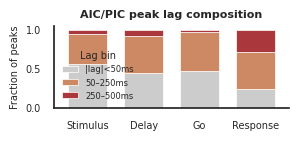

lag_bin,|lag|<50ms,50–250ms,250–500ms
phase_norm,,,
stimulus,82,57,8
delay,65,69,11
go,75,80,5
response,206,402,239


In [11]:
df = peaks_df.copy()
df["source_roi"] = df["source_roi"].replace(ROI_MAP)
df["target_roi"] = df["target_roi"].replace(ROI_MAP)
df["phase_norm"] = df["phase"].astype(str).str.lower().str.strip()

focus_mask = df["source_roi"].isin(FOCUS_ROIS) | df["target_roi"].isin(FOCUS_ROIS)
df = df[focus_mask & df["phase_norm"].isin(PHASES)].copy()
df = df[~((df["source_roi"].isin(FOCUS_ROIS)) & (df["target_roi"].isin(FOCUS_ROIS)))].copy()

abs_lag = df["peak_lag_s"].abs()
df["lag_bin"] = pd.cut(
    abs_lag,
    bins=[-np.inf, 0.05, 0.25, np.inf],
    labels=["|lag|<50ms", "50–250ms", "250–500ms"],
)

counts = (
    df.groupby(["phase_norm", "lag_bin"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(PHASES)
    .fillna(0)
)
frac = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0)

fig, ax = plt.subplots(figsize=(8 * cm, 4 * cm))
frac.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#cccccc", orange, red],
    width=0.7,
    edgecolor="white",
    linewidth=0.5,
)
ax.set_ylabel("Fraction of peaks", fontsize=7)
ax.set_xlabel("")
ax.set_xticklabels([p.capitalize() for p in PHASES], rotation=0, fontsize=7)
ax.tick_params(labelsize=7)
ax.legend(fontsize=6, frameon=False, title="Lag bin", title_fontsize=7)
ax.set_title("AIC/PIC peak lag composition", fontsize=8, fontweight="bold")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

display(counts.astype(int))

## Optional: AIC / PIC partner density (brain)

Renders pial partner-density maps for **each phase × {AIC, PIC}**
(4 phases × 2 ROIs = **8 figures**).
Requires `mne` + `pyvista` and access to `RECON_DIR`. Set `RUN_BRAIN = False`
to skip on a login node without a working 3D backend.

[brain] rendering up to 8 figures (4 phases × 2 ROIs)
[brain] Stimulus AIC: pairs=84, focus=33, partners=71


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-19 11:06:25.015 ( 709.072s) [    7FF221EE2740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x554d9e10): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

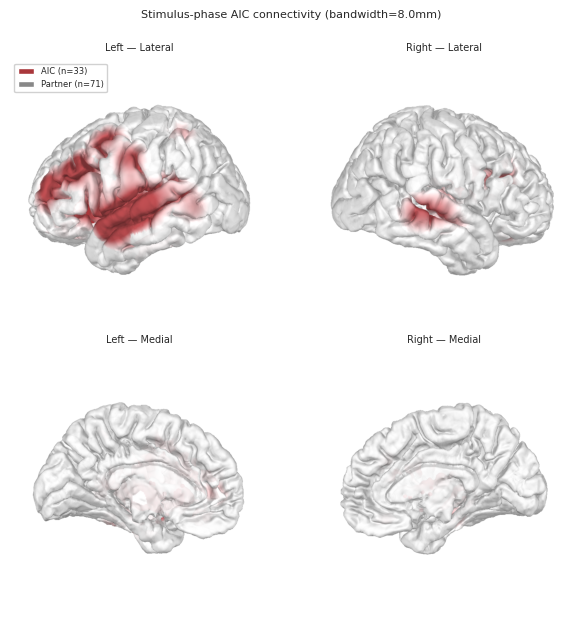

[brain] Stimulus PIC: pairs=74, focus=27, partners=68


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-19 11:06:27.860 ( 711.917s) [    7FF221EE2740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x619a76a0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

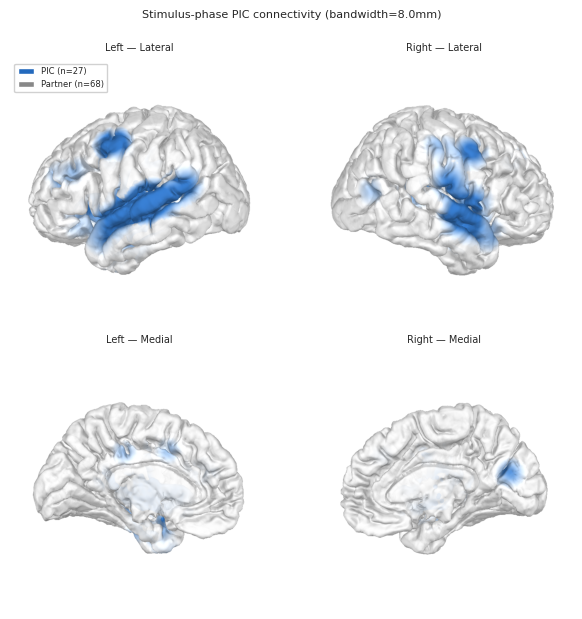

[brain] Delay AIC: pairs=102, focus=42, partners=80


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-19 11:06:30.727 ( 714.784s) [    7FF221EE2740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x625ab520): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

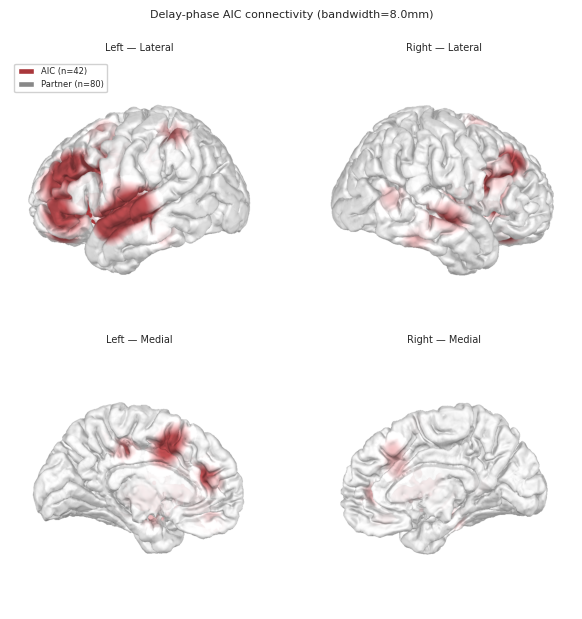

[brain] Delay PIC: pairs=56, focus=22, partners=49


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-19 11:06:33.548 ( 717.605s) [    7FF221EE2740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x5e752470): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

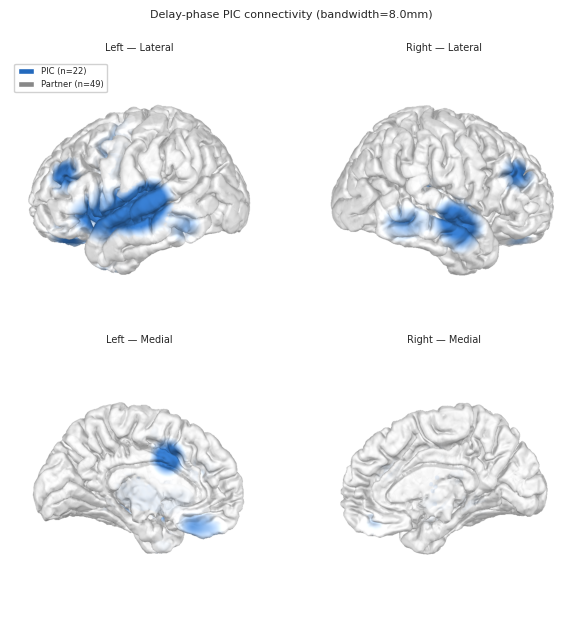

[brain] Go AIC: pairs=124, focus=53, partners=105


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-19 11:06:36.410 ( 720.467s) [    7FF221EE2740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x472c3d40): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

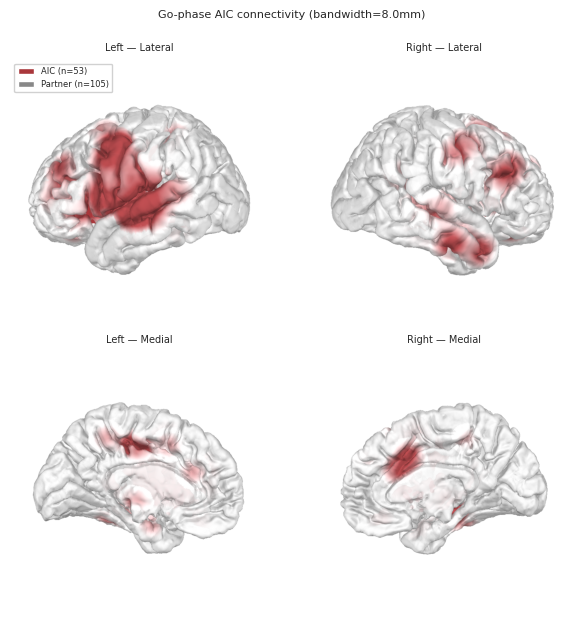

[brain] Go PIC: pairs=50, focus=14, partners=40


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-19 11:06:39.212 ( 723.269s) [    7FF221EE2740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x606cfdc0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

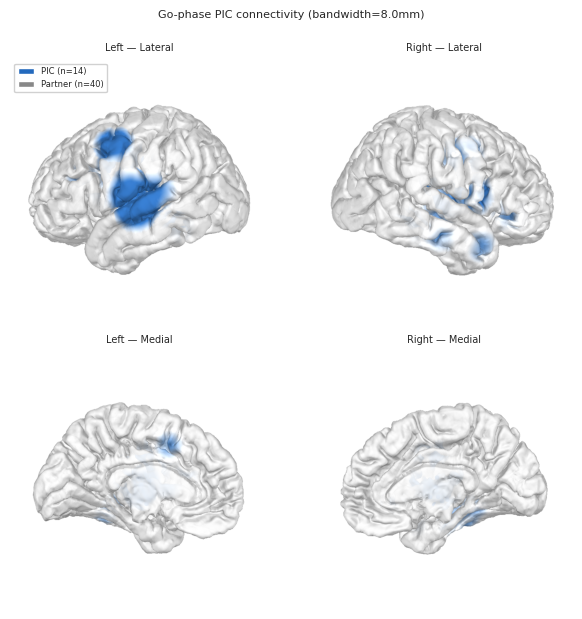

[brain] Response AIC: pairs=221, focus=73, partners=193


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-19 11:06:42.240 ( 726.297s) [    7FF221EE2740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x8192a610): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

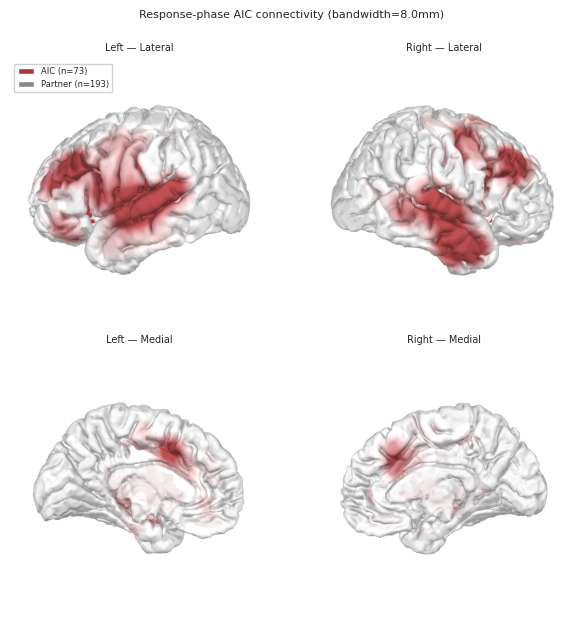

[brain] Response PIC: pairs=733, focus=32, partners=160


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-19 11:06:45.184 ( 729.241s) [    7FF221EE2740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x2ffdf750): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

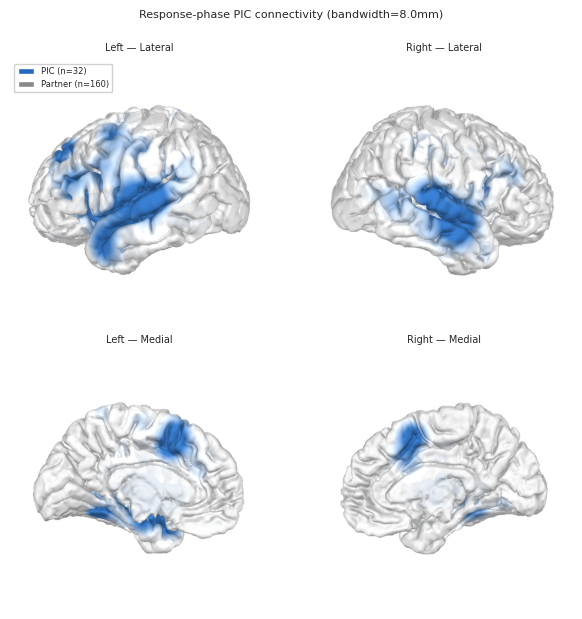

In [15]:
RUN_BRAIN = True  # set True to render AIC/PIC partner density on pial surface
BRAIN_FOCUS_ROIS = ["AIC", "PIC"]
BRAIN_PHASES = ["stimulus", "delay", "go", "response"]  # 4 × 2 = 8 figures

if RUN_BRAIN:
    import mne
    import pyvista as pv
    import matplotlib.colors as mcolors
    from matplotlib.colors import ListedColormap
    from matplotlib.patches import Patch
    from scipy.spatial import cKDTree
    from scipy.spatial.distance import cdist
    from mne.viz import Brain

    mne.viz.set_3d_backend("notebook")

    lh_pial_coords, _ = mne.read_surface(f"{RECON_DIR}/cvs_avg35_inMNI152/surf/lh.pial")
    rh_pial_coords, _ = mne.read_surface(f"{RECON_DIR}/cvs_avg35_inMNI152/surf/rh.pial")
    lh_tree = cKDTree(lh_pial_coords)
    rh_tree = cKDTree(rh_pial_coords)

    bandwidth = 8.0
    max_distance = 15.0
    n_colors = 256
    coord_lookup = channel_meta.set_index("channel")[["x", "y", "z"]]
    roi_colors = {"AIC": red, "PIC": blue}

    def compute_density(surface_coords, electrode_coords, bandwidth, max_distance):
        if len(electrode_coords) == 0:
            return np.zeros(len(surface_coords)), np.zeros(len(surface_coords), dtype=bool)
        distances = cdist(surface_coords, electrode_coords)
        mask = distances.min(axis=1) < max_distance
        density = np.exp(-distances**2 / (2 * bandwidth**2)).sum(axis=1)
        density[~mask] = 0
        return density, mask

    def add_electrodes(brain, coords, tree, surf_coords, color, size=14):
        if len(coords) == 0:
            return
        _, idx = tree.query(coords)
        cloud = pv.PolyData(surf_coords[idx])
        brain._renderer.plotter.add_mesh(
            cloud, render_points_as_spheres=True, point_size=size,
            color=color, lighting=False, smooth_shading=False, opacity=1.0,
        )

    def make_density_cmap(focus_color):
        base = np.array(mcolors.to_rgb(focus_color))
        colors_list = [[1, 1, 1, 0]]
        for i in range(1, n_colors):
            t = i / (n_colors - 1)
            rgb = (1 - t) * np.array([1, 1, 1]) + t * base
            colors_list.append(list(rgb) + [0.9])
        return ListedColormap(colors_list)

    phase_base = sig_roi_df[
        sig_roi_df["source_roi"].notna() & sig_roi_df["target_roi"].notna()
    ].copy()
    phase_base["phase_norm"] = phase_base["phase"].astype(str).str.lower().str.strip()

    n_expected = len(BRAIN_PHASES) * len(BRAIN_FOCUS_ROIS)
    print(f"[brain] rendering up to {n_expected} figures "
          f"({len(BRAIN_PHASES)} phases × {len(BRAIN_FOCUS_ROIS)} ROIs)")

    for phase in BRAIN_PHASES:
        phase_df = phase_base[phase_base["phase_norm"] == phase].copy()

        for roi in BRAIN_FOCUS_ROIS:
            focus_color = roi_colors.get(roi, red)
            density_cmap = make_density_cmap(focus_color)

            conn_df = phase_df[
                (phase_df["source_roi"] == roi) ^ (phase_df["target_roi"] == roi)
            ].copy()
            if conn_df.empty:
                print(f"[brain] {phase.capitalize()} {roi}: no significant pairs, skip.")
                continue

            conn_df["focus_channel"] = np.where(
                conn_df["source_roi"] == roi, conn_df["source_channel"], conn_df["target_channel"]
            )
            conn_df["partner_channel"] = np.where(
                conn_df["source_roi"] == roi, conn_df["target_channel"], conn_df["source_channel"]
            )

            focus_channels = set(conn_df["focus_channel"]) - set(exclude_chn)
            partner_channels = set(conn_df["partner_channel"]) - set(exclude_chn)

            focus_coords = coord_lookup.loc[
                [c for c in focus_channels if c in coord_lookup.index]
            ].values
            partner_coords = coord_lookup.loc[
                [c for c in partner_channels if c in coord_lookup.index]
            ].values

            print(
                f"[brain] {phase.capitalize()} {roi}: pairs={len(conn_df)}, "
                f"focus={len(focus_channels)}, partners={len(partner_channels)}"
            )

            mask_focus_lh = focus_coords[:, 0] < 0 if len(focus_coords) else np.array([], dtype=bool)
            mask_focus_rh = focus_coords[:, 0] > 0 if len(focus_coords) else np.array([], dtype=bool)
            mask_par_lh = partner_coords[:, 0] < 0 if len(partner_coords) else np.array([], dtype=bool)
            mask_par_rh = partner_coords[:, 0] > 0 if len(partner_coords) else np.array([], dtype=bool)

            lh_density, lh_dmask = compute_density(
                lh_pial_coords, partner_coords[mask_par_lh], bandwidth, max_distance
            )
            rh_density, rh_dmask = compute_density(
                rh_pial_coords, partner_coords[mask_par_rh], bandwidth, max_distance
            )

            all_valid = np.concatenate([
                lh_density[lh_dmask & (lh_density > 0)],
                rh_density[rh_dmask & (rh_density > 0)],
            ])
            vmin_d = float(np.percentile(all_valid, 10)) if len(all_valid) else 0.0
            vmax_d = float(np.percentile(all_valid, 80)) if len(all_valid) else 1.0

            def render_brain(hemi, view, density, dmask, surf_coords, tree, focus_mask_h):
                brain = Brain(
                    "cvs_avg35_inMNI152", subjects_dir=RECON_DIR, surf="pial", hemi=hemi,
                    background="white", show=False, cortex=(0.9, 0.9, 0.9), alpha=0.9, size=(800, 800),
                )
                data = np.zeros(len(surf_coords))
                has_data = dmask & (density > 0)
                if has_data.any():
                    norm = np.clip((density[has_data] - vmin_d) / (vmax_d - vmin_d + 1e-12), 0, 1)
                    data[has_data] = 1 + norm * (n_colors - 2)
                brain.add_data(
                    data, hemi=hemi, colormap=density_cmap, alpha=1.0,
                    colorbar=False, fmin=0, fmax=n_colors - 1,
                )
                if focus_mask_h.any():
                    add_electrodes(
                        brain, focus_coords[focus_mask_h], tree, surf_coords,
                        color=focus_color, size=14,
                    )
                brain.show_view(view=view, distance=400)
                return brain

            panels = [
                ("lh", "lateral", lh_density, lh_dmask, lh_pial_coords, lh_tree, mask_focus_lh, "Left — Lateral"),
                ("rh", "lateral", rh_density, rh_dmask, rh_pial_coords, rh_tree, mask_focus_rh, "Right — Lateral"),
                ("lh", "medial", lh_density, lh_dmask, lh_pial_coords, lh_tree, mask_focus_lh, "Left — Medial"),
                ("rh", "medial", rh_density, rh_dmask, rh_pial_coords, rh_tree, mask_focus_rh, "Right — Medial"),
            ]

            screenshots, brains = [], []
            for hemi, view, density, dmask, surf_coords, tree, focus_mask_h, title in panels:
                b = render_brain(hemi, view, density, dmask, surf_coords, tree, focus_mask_h)
                screenshots.append((b.screenshot(mode="rgb"), title))
                brains.append(b)

            fig, axes = plt.subplots(2, 2, figsize=(16 * cm, 16 * cm))
            for ax, (img, title) in zip(axes.flat, screenshots):
                ax.imshow(img)
                ax.axis("off")
                ax.set_title(title, fontsize=fontsize)

            axes[0, 0].legend(
                handles=[
                    Patch(facecolor=focus_color, label=f"{roi} (n={len(focus_channels)})"),
                    Patch(facecolor="#888888", label=f"Partner (n={len(partner_channels)})"),
                ],
                loc="upper left", fontsize=fontsize - 1, framealpha=0.9,
            )
            plt.suptitle(
                f"{phase.capitalize()}-phase {roi} connectivity (bandwidth={bandwidth}mm)",
                fontsize=fontsize + 1,
            )
            for b in brains:
                b.close()
            plt.tight_layout()
            plt.show()
else:
    print("Brain panel skipped (set RUN_BRAIN = True to render).")